In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

2025-11-13 11:31:10.758570: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-13 11:31:10.758841: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 11:31:10.794319: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 11:32:07.987065: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [3]:
mdata = mu.read("merged_EAE_singleClone.h5mu")
mdata2 = mdata.copy()

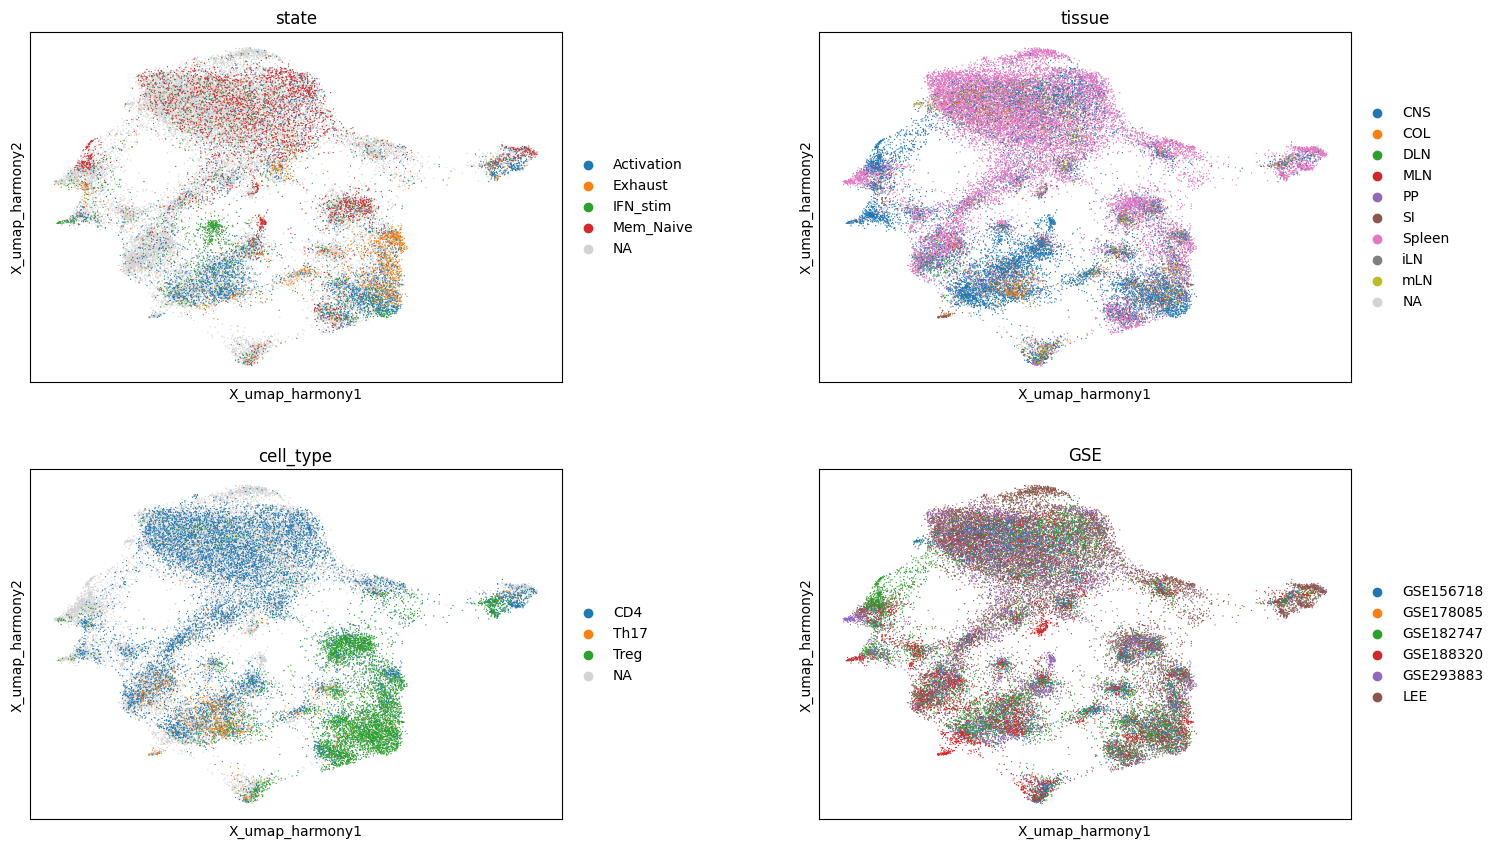

In [4]:
n_neighbors = 30
min_dist = 0.2
spread = 1.5

sc.pp.neighbors(mdata["gex"], n_neighbors = n_neighbors, use_rep='X_pca_harmony', key_added = 'neighbors_harmony')
sc.tl.umap(mdata["gex"], min_dist=min_dist, spread=spread, neighbors_key = 'neighbors_harmony', key_added = 'X_umap_harmony')
sc.pl.embedding(mdata["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2, wspace=0.35)

## Add CV to mdata2

In [5]:
cv_score_cols = [f"CV_score_{i}" for i in range(4)]
cv_scores = mdata2["gex"].obs[cv_score_cols].to_numpy()

mdata2["gex"].obsm["CV_scores"] = cv_scores
x_pca_harmony = mdata2["gex"].obsm.get("X_pca_harmony")
if x_pca_harmony is None:
    raise KeyError("`X_pca_harmony` not found in `mdata2['gex'].obsm`. Ensure Harmony embedding is computed before concatenation.")

mdata2["gex"].obsm["X_pca_harmony_cv"] = np.concatenate([x_pca_harmony, cv_scores], axis=1)


In [26]:
sc.pp.neighbors(mdata2["gex"], n_neighbors=n_neighbors, use_rep="X_pca_harmony_cv", random_state=0)
sc.tl.umap(mdata2["gex"], min_dist=min_dist, spread=spread)

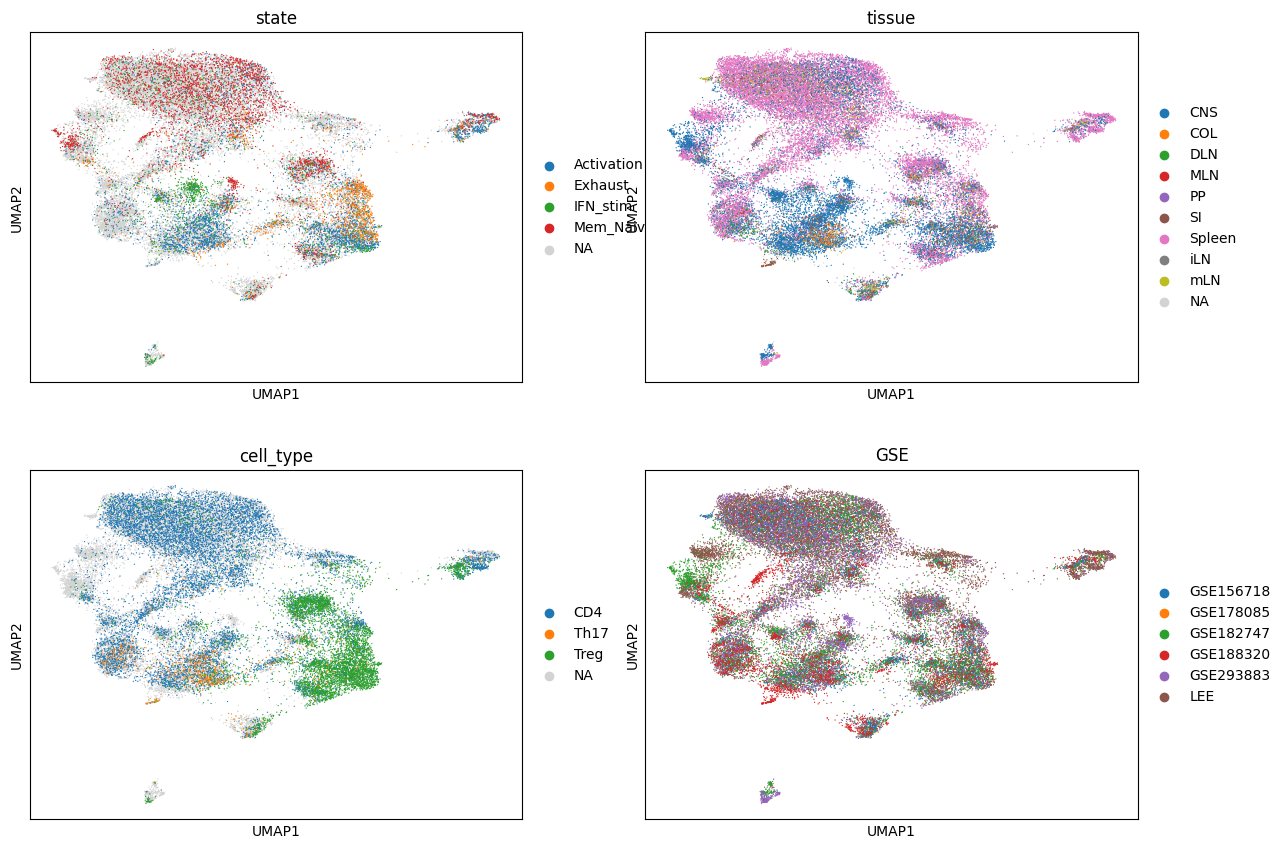

In [27]:
sc.pl.umap(mdata2["gex"], color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

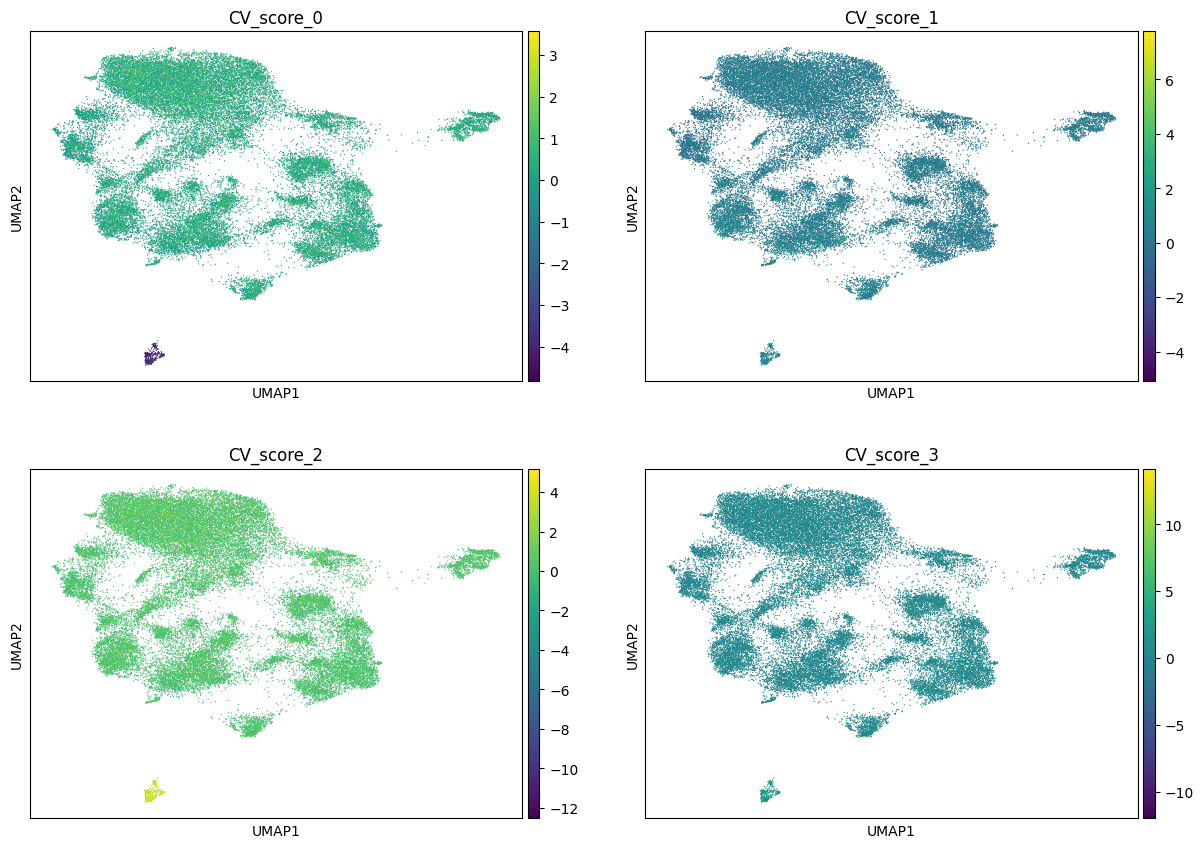

In [28]:
sc.pl.umap(mdata2["gex"], color=cv_score_cols, ncols=2,)

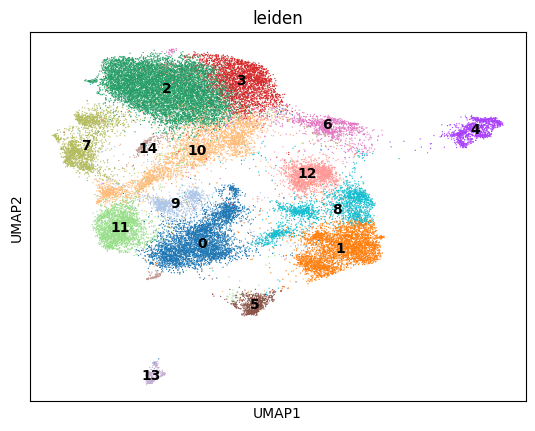

In [29]:
sc.tl.leiden(mdata2["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph', random_state=0)
sc.pl.umap(mdata2["gex"], color="leiden", legend_loc="on data")

In [36]:
target_clusters = {"13"}

leiden_raw = mdata2["gex"].obs["leiden"]
leiden_mdata2 = leiden_raw.astype(str)
leiden_mdata2[leiden_raw.isna()] = "other"
leiden_mdata2 = leiden_mdata2.replace({"nan": "other", "None": "other"})

mdata["gex"].obs["leiden_mdata2"] = leiden_mdata2

highlight_mask = mdata["gex"].obs["leiden_mdata2"].isin(target_clusters)
cluster_values = np.where(highlight_mask, mdata["gex"].obs["leiden_mdata2"], "other")
ordered_categories = sorted(target_clusters) + ["other"]

if "leiden_target" in mdata["gex"].obs:
    del mdata["gex"].obs["leiden_target"]

mdata["gex"].obs["leiden_target"] = pd.Categorical(cluster_values, categories=ordered_categories, ordered=False)


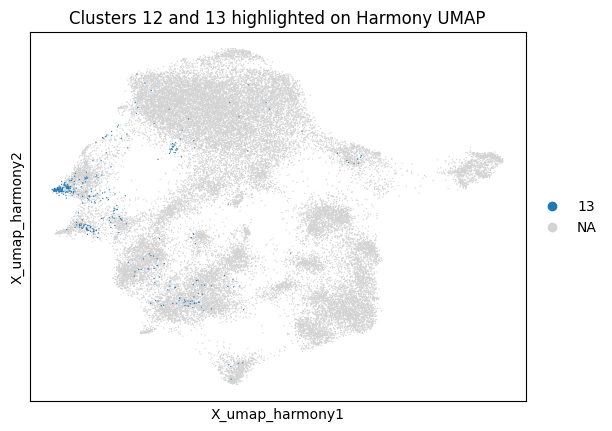

In [37]:
sc.pl.embedding(
    mdata["gex"],
    basis="X_umap_harmony",
    neighbors_key="neighbors_harmony",
    color="leiden_target",
    groups=sorted(target_clusters),
    # legend_loc="on data",
    title="Clusters 12 and 13 highlighted on Harmony UMAP"
)


In [38]:
obs = mdata2["gex"].obs
cluster_mask = obs["leiden"].astype(str).isin(target_clusters)

categorical_columns = ["state", "tissue", "cell_type", "GSE"]
summary_rows = []

for col in categorical_columns:
    series = obs.loc[cluster_mask, col]
    counts = series.value_counts(dropna=False)
    total = counts.sum()
    for label, count in counts.items():
        display_label = label if pd.notna(label) else "NA"
        summary_rows.append(
            {
                "category": col,
                "label": display_label,
                "count": int(count),
                "percentage": round(count / total * 100, 2),
            }
        )

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["category", "percentage"], ascending=[True, False]
)
summary_df.reset_index(drop=True, inplace=True)
summary_df


,category,label,count,percentage
0,GSE,GSE293883,232,59.34
1,GSE,GSE182747,123,31.46
2,GSE,LEE,24,6.14
3,GSE,GSE156718,7,1.79
4,GSE,GSE188320,5,1.28
5,GSE,GSE178085,0,0.00
6,cell_type,NA,352,90.03
7,cell_type,Treg,28,7.16
8,cell_type,CD4,7,1.79
9,cell_type,Th17,4,1.02


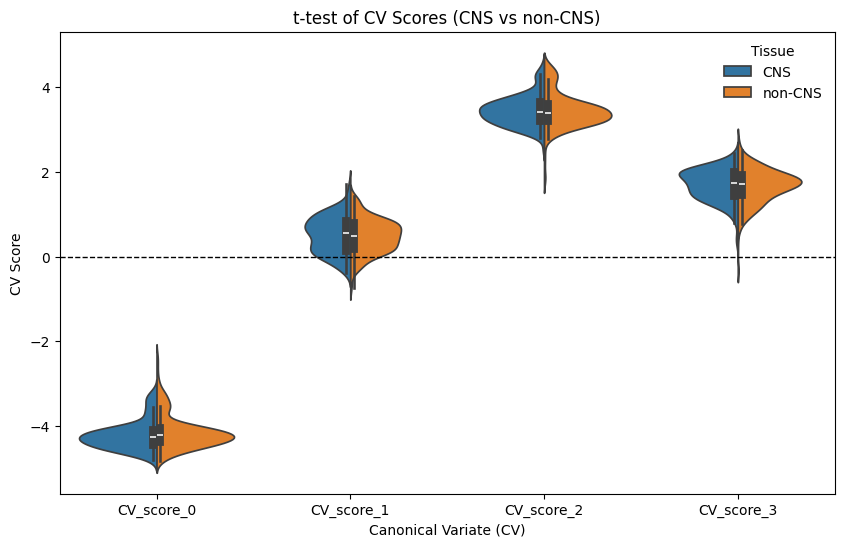

In [45]:
import seaborn as sns
obs_inTarget = obs.loc[cluster_mask, :]
dim_cca = 4

cv_cols = [f'CV_score_{i}' for i in range(dim_cca)]
df_long = obs_inTarget.melt(id_vars='Tissue_group',
                   value_vars=cv_cols,
                   var_name='CV_component',
                   value_name='CV_score')

plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=df_long,
    x='CV_component',
    y='CV_score',
    hue='Tissue_group',
    split=True,
    inner='box',
    palette={'CNS': 'tab:blue', 'non-CNS': 'tab:orange'},
)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title("t-test of CV Scores (CNS vs non-CNS)")
plt.xlabel('Canonical Variate (CV)')
plt.ylabel('CV Score')
plt.legend(title='Tissue', frameon=False)

## DEA

In [80]:
lowCorr_subset_mask = (
    (mdata2["gex"].obs["GSE"] == "GSE293883")
    & (mdata2["gex"].obs["tissue"] == "Spleen")
)

subset_adata = mdata2["gex"][lowCorr_subset_mask].copy()

# targetCluster_mask = mdata2["gex"].obs["leiden"].isin(target_clusters)
# highCorr_mask = lowCorr_subset_mask & targetCluster_mask

subset_adata.obs["high_corr"] = subset_adata.obs["leiden"].isin(target_clusters).astype('string')

sc.tl.rank_genes_groups(
    subset_adata,
    groupby="high_corr",
    groups= ['True'],
    reference="rest",
    method="t-test",
    n_genes = 30
)

cluster12_rank_df = sc.get.rank_genes_groups_df(subset_adata, group='True')


In [81]:
list(cluster12_rank_df['names'])

['Id2',
 'Cxcr6',
 'St6galnac3',
 'Pde3b',
 'Ctsw',
 'Cd226',
 'Kcnq5',
 'AW112010',
 'Ccl5',
 'Nr3c1',
 'Serinc3',
 'Il2rb',
 'Tex2',
 'Nedd4',
 'Rora',
 'Zbtb16',
 'Ikzf3',
 'Chn2',
 'Nkg7',
 '4933406I18Rik',
 'Gm57204',
 'Lyst',
 'Asb2',
 'Cd160',
 'Cxcr3',
 'Dusp2',
 'B2m',
 'Atp8a2',
 'Ptpn22',
 'Ckb']

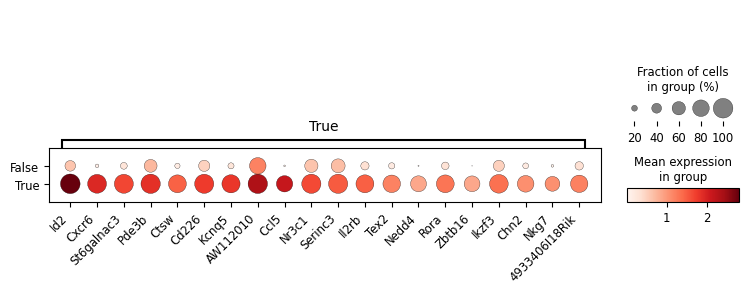

In [82]:
dp = sc.pl.rank_genes_groups_dotplot(subset_adata,  groupby="high_corr", groups= ['True'], n_genes = 20, show=False)

ax = dp["mainplot_ax"]
for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.tight_layout()
plt.show()

In [83]:
cluster12_mask = subset_adata.obs["leiden"] == "12"
cluster12_count = int(cluster12_mask.sum())
subset_total = int(subset_adata.n_obs)
cluster12_pct = round(cluster12_count / subset_total * 100, 2)

print(f"Cluster 12 cells: {cluster12_count} of {subset_total} subset cells")
print(f"Percentage of subset in cluster 12: {cluster12_pct}%")


Cluster 12 cells: 266 of 3858 subset cells
Percentage of subset in cluster 12: 6.89%
